<div align="center">

<img src="https://raw.githubusercontent.com/winstonsmith1897/DantinoX/main/docs/images/dantinox.png" width="150" alt="DantinoX"/>

</div>

# DantinoX · 04 — Benchmarking & Profiling

<div align="center">

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/winstonsmith1897/DantinoX/blob/main/docs/notebooks/04_benchmarking.ipynb) &nbsp;
[![PyPI](https://img.shields.io/pypi/v/dantinox?color=7c3aed)](https://pypi.org/project/dantinox/) &nbsp;
[![GitHub](https://img.shields.io/badge/GitHub-DantinoX-181717?logo=github)](https://github.com/winstonsmith1897/DantinoX)

</div>

*Measure FLOPs, latency, and throughput — sweep configs and visualise the results.*

---

**You’ll learn**
- Analytical FLOPs — `count_flops` / `dx.profile`
- Wall-clock latency — `LatencyTracker`
- Full benchmark sweep — `BenchmarkSuite.default()`
- Attention comparison — MHA vs GQA vs MLA
- Parameter counts & the `Visualizer`

**Runtime** — GPU (T4 or better)

---

In [ ]:
!pip install -q uv
!uv pip install --system -q -U "dantinox[data,hub,elf,benchmark]" "flax>=0.12,<0.13" "jax[cuda12]"

In [1]:
import dantinox as dx

dx.doctor()   # environment health check — jax/flax/CUDA alignment, GPU visibility

  warnings.warn(



  ████                █    █                █   █
  █   █  ███  ████  █████       ████   ███   █ █ 
  █   █ █   █ █   █   █    █    █   █ █   █   █  
  █   █ █  ██ █   █   █    █    █   █ █   █  █ █ 
  ████   ████ █   █   ██   ███  █   █  ███  █   █

  JAX/Flax transformer library  v0.4.7



DantinoX doctor
  dantinox             0.4.7
  jax                  0.9.2
  jaxlib               0.9.2
  flax                 0.12.6
  optax                0.2.8
  jax-cuda12-plugin    0.10.0
  jax-cuda12-pjrt      0.10.0
  transformers         4.44.2
  datasets             4.8.5
  devices              cuda:0
  ✗ jax-cuda12-plugin 0.10.0 vs jaxlib 0.9.2 — the CUDA plugin must match jaxlib exactly (PJRT errors otherwise); fix: pip install -U "jax[cuda12]"


{'versions': {'dantinox': '0.4.7',
  'jax': '0.9.2',
  'jaxlib': '0.9.2',
  'flax': '0.12.6',
  'optax': '0.2.8',
  'jax-cuda12-plugin': '0.10.0',
  'jax-cuda12-pjrt': '0.10.0',
  'transformers': '4.44.2',
  'datasets': '4.8.5'},
 'problems': ['jax-cuda12-plugin 0.10.0 vs jaxlib 0.9.2 — the CUDA plugin must match jaxlib exactly (PJRT errors otherwise); fix: pip install -U "jax[cuda12]"'],
 'warnings': [],
 'gpu': ['cuda:0'],
 'ok': False}

In [2]:
import jax
import pandas as pd
from flax import nnx

import dantinox as dx
from dantinox.benchmarking import BenchmarkConfig, BenchmarkSuite
from dantinox.profiling import LatencyTracker, count_flops

cfg      = dx.ModelConfig(paradigm="ar", dim=256, n_heads=4, num_blocks=4, vocab_size=2000)
paradigm = dx.Paradigm(cfg)
model    = paradigm.build_model(nnx.Rngs(0))
print(f'Parameters: {paradigm.num_parameters(model):,}')

Parameters: 4,718,848


## 1. Analytical FLOPs

`dx.profile` computes FLOPs analytically — no GPU needed, no warmup.

In [3]:
print('FLOPs by sequence length:')
for seq_len in [64, 128, 256, 512, 1024]:
    flops = count_flops(cfg, seq_len=seq_len, batch_size=1)
    print(f'  seq_len={seq_len:5d}  total={flops.total / 1e9:.3f} GFLOPs')

FLOPs by sequence length:
  seq_len=   64  total=0.611 GFLOPs
  seq_len=  128  total=1.238 GFLOPs
  seq_len=  256  total=2.544 GFLOPs
  seq_len=  512  total=5.356 GFLOPs
  seq_len= 1024  total=11.786 GFLOPs


In [4]:
# Compare FLOPs across attention types at seq_len=512
attn_cfgs = [
    ('MHA',            dx.ModelConfig(dim=256, n_heads=4, head_size=64, num_blocks=4,
                                      vocab_size=2000, attention='mha')),
    ('GQA kv_heads=2', dx.ModelConfig(dim=256, n_heads=4, head_size=64, num_blocks=4,
                                      vocab_size=2000, attention='gqa', kv_heads=2)),
    ('GQA kv_heads=1', dx.ModelConfig(dim=256, n_heads=4, head_size=64, num_blocks=4,
                                      vocab_size=2000, attention='gqa', kv_heads=1)),
    ('MLA',            dx.ModelConfig(dim=256, n_heads=4, head_size=64, num_blocks=4,
                                      vocab_size=2000, attention='mla')),
]

print('\nFLOPs by attention type (seq_len=512):')
for name, c in attn_cfgs:
    flops = count_flops(c, seq_len=512, batch_size=1)
    p = dx.Paradigm(c)
    n = p.num_parameters(p.build_model(nnx.Rngs(0)))
    print(f'  {name:20s}  {n/1e6:6.2f}M params  {flops.total/1e9:.3f} GFLOPs')


FLOPs by attention type (seq_len=512):
  MHA                     4.72M params  5.356 GFLOPs


  GQA kv_heads=2          4.46M params  5.356 GFLOPs


  GQA kv_heads=1          4.33M params  5.356 GFLOPs


  MLA                     5.32M params  5.356 GFLOPs


## 2. Wall-Clock Latency

`LatencyTracker` measures actual GPU throughput in tokens/s with warmup.

In [5]:
tracker = LatencyTracker()
x = jax.random.randint(jax.random.PRNGKey(0), (4, 256), 0, 2000)

# Warmup (forces JIT compilation)
for _ in range(5):
    _ = model(x)

# Measure
for _ in range(20):
    with tracker.measure(n_tokens=4 * 256):
        _ = model(x)

print(tracker.result())

Profiling (20 samples, 20,480 tokens):
  latency mean : 67.75 ms
  latency p50  : 67.92 ms
  latency p99  : 75.84 ms
  throughput   : 15,115 tokens/s


## 3. Parameter Count Across Model Sizes

In [6]:
size_cfgs = [
    ('Tiny 13M',   dx.ModelConfig(dim=128,  n_heads=2, head_size=64, num_blocks=4,  vocab_size=2000)),
    ('Small 50M',  dx.ModelConfig(dim=256,  n_heads=4, head_size=64, num_blocks=8,  vocab_size=2000)),
    ('Medium 125M',dx.ModelConfig(dim=512,  n_heads=8, head_size=64, num_blocks=12, vocab_size=2000)),
    ('Large 350M', dx.ModelConfig(dim=1024, n_heads=16,head_size=64, num_blocks=24, vocab_size=2000)),
]

print(f'{"Name":15s}  {"Params":>10s}  {"GFLOPs @512":>12s}')
for name, c in size_cfgs:
    p = dx.Paradigm(c)
    m = p.build_model(nnx.Rngs(0))
    n = p.num_parameters(m)
    f = count_flops(c, seq_len=512, batch_size=1).total / 1e9
    print(f'{name:15s}  {n/1e6:>8.1f}M  {f:>12.2f}')

Name                 Params   GFLOPs @512


Tiny 13M              1.3M          1.60
Small 50M             8.9M         10.19


Medium 125M          51.4M         55.81


Large 350M          405.0M        427.30


## 4. Full Benchmark Suite

`BenchmarkSuite.default()` runs a sweep over sequence lengths and batch sizes,
measuring throughput, latency, memory, and perplexity.

In [7]:
bcfg   = BenchmarkConfig(
    seq_lens    = [64, 128, 256],
    batch_sizes = [1, 4, 16],
    n_warmup    = 3,
    n_measure   = 10,
    eval_batches= 10,
)
report = BenchmarkSuite.default(bcfg).run(paradigm, model, save_csv='/tmp/bench.csv')
print(report.summary())

[perplexity] no data_source — skipping. Pass PerplexityTask('data/val.txt') to evaluate.


BenchmarkSuite  —  3 task(s)  (35.2 s total)
  model: paradigm=Paradigm, n_params=4718848, dim=256, num_blocks=4, n_heads=4
  [throughput]  tps_seq64=1028.3367  tps_seq128=1906.6768  tps_seq256=4019.9245  tps_bs1=1000.2384  tps_bs4=4063.3358  tps_bs16=16301.8817  peak_tps=16301.8817
  [latency]  prefill_mean_ms=62.0488  prefill_p99_ms=64.4942
  [perplexity]  perplexity=nan  eval_loss=nan


## 5. Benchmark Across Attention Configs

In [8]:
bcfg_quick = BenchmarkConfig(
    seq_lens    = [64, 128],
    batch_sizes = [1, 4],
    n_warmup    = 1,
    n_measure   = 5,
    eval_batches= 5,
)

rows = []
for name, c in attn_cfgs:
    p = dx.Paradigm(c)
    m = p.build_model(nnx.Rngs(0))
    rep = BenchmarkSuite.default(bcfg_quick).run(p, m)
    df_rep = rep.to_dataframe()
    thr = df_rep[df_rep['task'] == 'throughput']
    lat = df_rep[df_rep['task'] == 'latency']
    row = {'attention': name}
    if not thr.empty and 'peak_tps' in thr.columns:
        row['peak_tps'] = float(thr['peak_tps'].iloc[0])
    if not lat.empty and 'latency_mean_ms' in lat.columns:
        row['latency_mean_ms'] = float(lat['latency_mean_ms'].iloc[0])
    rows.append(row)

df_cmp = pd.DataFrame(rows)
print(df_cmp[['attention', 'peak_tps', 'latency_mean_ms']].to_string(index=False))

[perplexity] no data_source — skipping. Pass PerplexityTask('data/val.txt') to evaluate.


[perplexity] no data_source — skipping. Pass PerplexityTask('data/val.txt') to evaluate.


[perplexity] no data_source — skipping. Pass PerplexityTask('data/val.txt') to evaluate.


[perplexity] no data_source — skipping. Pass PerplexityTask('data/val.txt') to evaluate.


     attention    peak_tps  latency_mean_ms
           MHA 4293.437423        63.793006
GQA kv_heads=2 4279.056504        60.460156
GQA kv_heads=1 4203.470845        58.198705
           MLA 2772.211164       110.948892


## 6. Visualization

Chart 'training_curve' requires constructor arguments — instantiate it manually and call chart.render() directly.


Chart 'throughput' requires constructor arguments — instantiate it manually and call chart.render() directly.


Chart 'throughput_batch' requires constructor arguments — instantiate it manually and call chart.render() directly.


Chart 'latency' requires constructor arguments — instantiate it manually and call chart.render() directly.


pareto


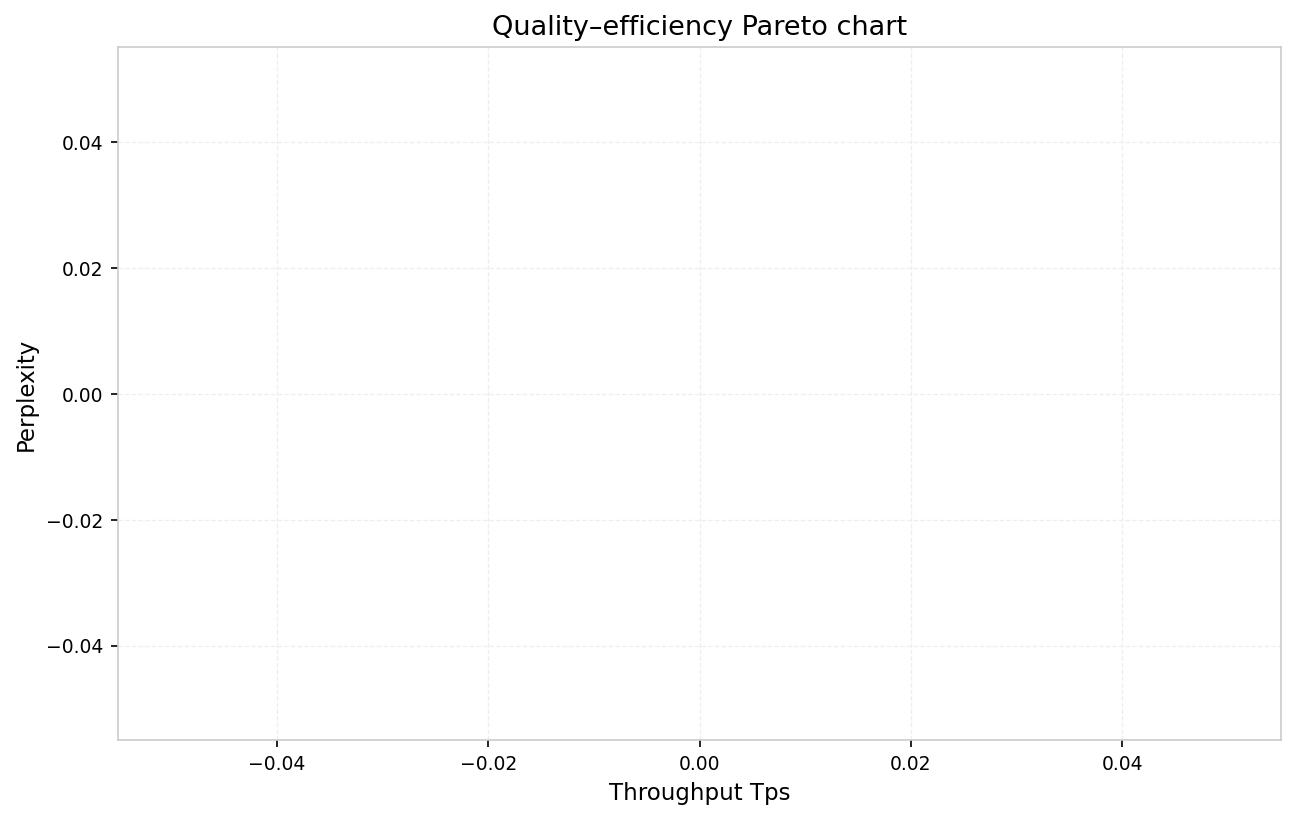

radar


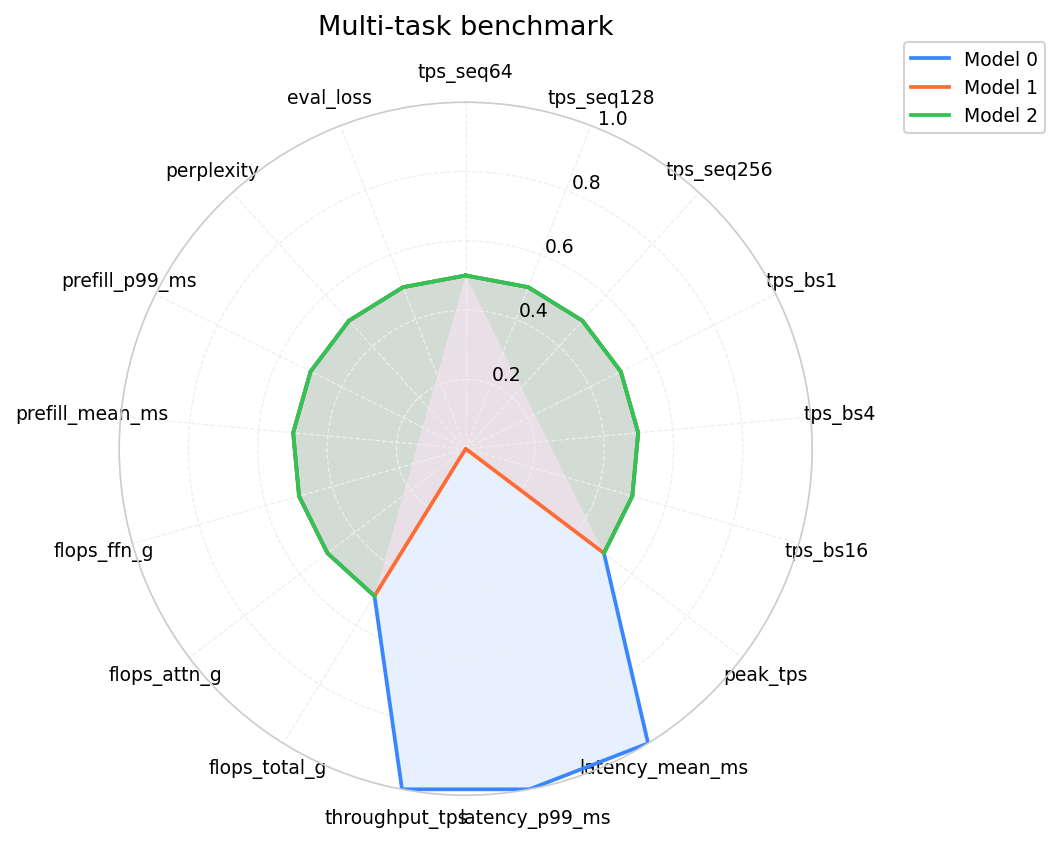

In [9]:
import os

from IPython.display import Image, display

from dantinox.visualization import Visualizer

os.makedirs('/tmp/plots', exist_ok=True)
df    = pd.read_csv('/tmp/bench.csv')
paths = Visualizer().render(df, out_dir='/tmp/plots')

for name, path in paths.items():
    print(name)
    display(Image(str(path)))

---

**Recap** — you learned:
- analytical FLOPs vs measured wall-clock latency
- sweeping configs with `BenchmarkSuite` and plotting with `Visualizer`

**Next →** [05 · LoRA Fine-Tuning](05_lora_fine_tuning.ipynb) · [Open in Colab](https://colab.research.google.com/github/winstonsmith1897/DantinoX/blob/main/docs/notebooks/05_lora_fine_tuning.ipynb)